# GliZNet — Full Benchmark Evaluation

Evaluates **GliZNet** (DeBERTa-v3-base backbone) on the same 10 datasets used in the GLiClass benchmark paper, reporting **macro F1** for direct comparison.

**Datasets**: CR, SST-2, SST-5, IMDb, 20-Newsgroups, Enron Spam, Financial PhraseBank, AG News, Emotion, Rotten Tomatoes

| Model | Avg macro F1 |
|---|---|
| GLiClass-large-v3.0 | 0.7417 |
| GLiClass-base-v3.0 | 0.7056 |
| **GliZNet curr (ours)** | **0.6888** |
| GliZNet prev (ours) | 0.6770 |
| GLiClass-modern-base-v3.0 | 0.6170 |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, ClassLabel
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

from gliznet import ZeroShotClassificationPipeline

DEVICE     = "cuda:0" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "../results/deberta_v3_base_20260522_111337/checkpoint-40000"
BATCH_SIZE = 64

print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_PATH}")

Device : cuda:0
Model  : ../results/deberta_v3_base_20260522_111337/checkpoint-40000


In [2]:
# Load GliZNet pipeline
pipeline = ZeroShotClassificationPipeline.from_pretrained(
    MODEL_PATH,
    classification_type="multi-label",
    device=DEVICE,
)
print("✓ GliZNet loaded")

# Sanity check
out = pipeline("I absolutely loved this film!", ["very positive", "positive", "negative", "very negative", "neutral"])
for ls in out.labels:
    print(f"  {ls.label:<12} {ls.score:.3f}")

Loading weights:   0%|          | 0/207 [00:00<?, ?it/s]

✓ GliZNet loaded
  very positive 0.916
  positive     0.794
  negative     0.006
  very negative 0.004
  neutral      0.002


## Dataset loading helpers

In [3]:
def get_test_split(ds):
    """Return the test (or fallback validation/train) split."""
    for key in ("test", "validation", "train"):
        if key in ds:
            return ds[key]
    raise ValueError("No usable split found")


def resolve_labels(split, label_col):
    """Return (class_names: list[str], int_to_str callable).
    Handles ClassLabel features and plain int/string columns.
    Classes are always returned as strings so the tokenizer never receives ints.
    """
    feat = split.features.get(label_col)
    if isinstance(feat, ClassLabel):
        classes = feat.names          # already list[str]
        to_str = lambda i: classes[i]
    else:
        raw_classes = sorted(set(split[label_col]))
        classes = [str(c) for c in raw_classes]
        to_str = lambda x: str(x)
    return classes, to_str


def prepare(ds, text_col="text", label_col="label", classes=None, to_str=None):
    """Return (texts: list[str], classes: list[str], true_labels: list[str])."""
    split = get_test_split(ds)
    if classes is None:
        classes, to_str = resolve_labels(split, label_col)
    raw = split[label_col]
    true_labels = [to_str(l) for l in raw]
    return list(split[text_col]), classes, true_labels

In [4]:
def predict_batch(texts, classes, batch_size=BATCH_SIZE):
    """Return the top predicted class string for each text."""
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="  inference", leave=False):
        batch_texts = texts[i : i + batch_size]
        outputs = pipeline(batch_texts, classes)
        for out in outputs:
            best = max(out.labels, key=lambda ls: ls.score)
            preds.append(best.label)
    return preds


def evaluate(preds, true_labels):
    return {
        "macro":    f1_score(true_labels, preds, average="macro"),
        "micro":    f1_score(true_labels, preds, average="micro"),
        "weighted": f1_score(true_labels, preds, average="weighted"),
    }

## Run evaluation on all benchmarks

## Dataset inspection — load each one and check columns / label format

In [5]:
def inspect(ds_id, config=None, text_col=None, label_col=None):
    """Load a dataset and print its splits, columns, feature types and a few label samples."""
    print(f"\n{'─'*60}")
    print(f"  {ds_id}  {'(' + config + ')' if config else ''}")
    print(f"{'─'*60}")
    ds = load_dataset(ds_id, config) if config else load_dataset(ds_id)
    print(f"  Splits   : {list(ds.keys())}")
    split = get_test_split(ds)
    print(f"  Split    : {len(split)} rows")
    print(f"  Columns  : {split.column_names}")
    print(f"  Features : {split.features}")
    if text_col:
        print(f"  Text[0]  : {str(split[text_col][0])[:120]}")
    if label_col:
        sample_labels = split[label_col][:5]
        print(f"  Labels[0:5]: {sample_labels}")
        feat = split.features.get(label_col)
        if isinstance(feat, ClassLabel):
            print(f"  Class names: {feat.names[:10]}{'...' if len(feat.names)>10 else ''}")
        else:
            unique = sorted(set(split[label_col]))
            print(f"  Unique labels ({len(unique)}): {unique[:10]}{'...' if len(unique)>10 else ''}")

In [6]:
DATASETS = [
    "SetFit/CR",
    "SetFit/sst2",
    "SetFit/sst5",
    "stanfordnlp/imdb",
    "SetFit/20_newsgroups",
    "SetFit/enron_spam",
    "mteb/financial_phrasebank",
    "ag_news",
    "dair-ai/emotion",
    "cornell-movie-review-data/rotten_tomatoes",
]

results_all = {}

for dataset_id in DATASETS:
    print(f"\n{'='*60}")
    print(f"  {dataset_id}")
    print(f"{'='*60}")
    try:
        # ── per-dataset loading ──────────────────────────────────────
        if dataset_id == "stanfordnlp/imdb":
            classes = ["negative", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id)
            texts, _, true_labels = prepare(ds, label_col="label", classes=classes, to_str=_to)

        elif dataset_id == "SetFit/enron_spam":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "SetFit/20_newsgroups":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")
            remap = {c: c.replace(".", " ") for c in classes}
            classes = [remap[c] for c in classes]
            true_labels = [remap[l] for l in true_labels]

        elif dataset_id in ("SetFit/CR", "SetFit/sst2", "SetFit/sst5"):
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "mteb/amazon_massive_intent":
            ds = load_dataset(dataset_id, "en")
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label")

        elif dataset_id == "mteb/banking77":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label_text")

        elif dataset_id == "mteb/financial_phrasebank":
            classes = ["negative", "neutral", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id, "sentences_allagree")
            texts, _, true_labels = prepare(ds, text_col="text", label_col="label", classes=classes, to_str=_to)

        else:
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds)

        print(f"  Samples : {len(texts)}")
        print(f"  Classes : {len(classes)}  → {classes[:6]}{'...' if len(classes) > 6 else ''}")

        preds  = predict_batch(texts, classes)
        scores = evaluate(preds, true_labels)
        results_all[dataset_id] = scores
        print(f"  macro F1 = {scores['macro']:.4f}  |  micro = {scores['micro']:.4f}")

    except Exception as exc:
        import traceback; traceback.print_exc()
        results_all[dataset_id] = {"macro": float("nan"), "micro": float("nan"), "weighted": float("nan")}

print("\n\n✓ All datasets done")



  SetFit/CR


Repo card metadata block was not found. Setting CardData to empty.


  Samples : 376
  Classes : 2  → ['negative', 'positive']


  inference:   0%|          | 0/6 [00:00<?, ?it/s]

  macro F1 = 0.9001  |  micro = 0.9096

  SetFit/sst2


...

  macro F1 = 0.7384  |  micro = 0.7586

  dair-ai/emotion
  Samples : 2000
  Classes : 6  → ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


  inference:   0%|          | 0/32 [00:00<?, ?it/s]

  macro F1 = 0.5135  |  micro = 0.5615

  cornell-movie-review-data/rotten_tomatoes
  Samples : 1066
  Classes : 2  → ['neg', 'pos']


  inference:   0%|          | 0/17 [00:00<?, ?it/s]

  macro F1 = 0.7357  |  micro = 0.7373


✓ All datasets done


## Results vs GLiClass benchmark

In [7]:
GLICLASS_BASE = {
    "SetFit/CR":                                    0.9127,
    "SetFit/sst2":                                  0.8959,
    "SetFit/sst5":                                  0.3236,
    "stanfordnlp/imdb":                             0.9248,
    "SetFit/20_newsgroups":                         0.5045,
    "SetFit/enron_spam":                            0.6252,
    "mteb/financial_phrasebank":                    0.9094,
    "ag_news":                                      0.7209,
    "dair-ai/emotion":                              0.4450,
    "cornell-movie-review-data/rotten_tomatoes":    0.7943,
}

GLICLASS_LARGE = {
    "SetFit/CR":                                    0.9281,
    "SetFit/sst2":                                  0.9176,
    "SetFit/sst5":                                  0.3798,
    "stanfordnlp/imdb":                             0.9366,
    "SetFit/20_newsgroups":                         0.5806,
    "SetFit/enron_spam":                            0.7574,
    "mteb/financial_phrasebank":                    0.9023,
    "ag_news":                                      0.7229,
    "dair-ai/emotion":                              0.4504,
    "cornell-movie-review-data/rotten_tomatoes":    0.8411,
}

GLICLASS_MODERN_BASE = {
    "SetFit/CR":                                    0.8936,
    "SetFit/sst2":                                  0.8982,
    "SetFit/sst5":                                  0.2885,
    "stanfordnlp/imdb":                             0.9154,
    "SetFit/20_newsgroups":                         0.3342,
    "SetFit/enron_spam":                            0.5903,
    "mteb/financial_phrasebank":                    0.4121,
    "ag_news":                                      0.7069,
    "dair-ai/emotion":                              0.4249,
    "cornell-movie-review-data/rotten_tomatoes":    0.7060,
}

# GliZNet previous best (bilinear, VICReg + custom data)
GLIZNET_PREV = {
    "SetFit/CR":                                    0.8783,
    "SetFit/sst2":                                  0.9010,
    "SetFit/sst5":                                  0.3739,
    "stanfordnlp/imdb":                             0.8909,
    "SetFit/20_newsgroups":                         0.4957,
    "SetFit/enron_spam":                            0.4983,
    "mteb/financial_phrasebank":                    0.7604,
    "ag_news":                                      0.7346,
    "dair-ai/emotion":                              0.4655,
    "cornell-movie-review-data/rotten_tomatoes":    0.7714,
}

rows = []
for ds_id in DATASETS:
    r = results_all.get(ds_id, {})
    rows.append({
        "dataset":                        ds_id.split("/")[-1],
        "GliZNet curr (ours)":            round(r.get("macro", float("nan")), 4),
        "GliZNet prev (ours)":            GLIZNET_PREV.get(ds_id, float("nan")),
        "GLiClass-large-v3":              GLICLASS_LARGE.get(ds_id, float("nan")),
        "GLiClass-base-v3":               GLICLASS_BASE.get(ds_id, float("nan")),
        "GLiClass-modern-base":           GLICLASS_MODERN_BASE.get(ds_id, float("nan")),
    })

df = pd.DataFrame(rows).set_index("dataset")

avg = df.mean(numeric_only=True)
avg.name = "AVERAGE"
df = pd.concat([df, avg.to_frame().T])
df["Δ curr vs prev"]  = (df["GliZNet curr (ours)"] - df["GliZNet prev (ours)"]).round(4)
df["Δ curr vs base"] = (df["GliZNet curr (ours)"] - df["GLiClass-base-v3"]).round(4)
df["Δ curr vs large"] = (df["GliZNet curr (ours)"] - df["GLiClass-large-v3"]).round(4)

pd.set_option("display.float_format", "{:.4f}".format)
_color = lambda v: (
    "color: green" if isinstance(v, float) and v > 0 else
    "color: red"   if isinstance(v, float) and v < 0 else ""
)
df.style.map(
    _color,
    subset=["Δ curr vs prev", "Δ curr vs base", "Δ curr vs large"],
)

,GliZNet curr (ours),GliZNet prev (ours),GLiClass-large-v3,GLiClass-base-v3,GLiClass-modern-base,Δ curr vs prev,Δ curr vs base,Δ curr vs large
CR,0.900100,0.878300,0.928100,0.912700,0.893600,0.021800,-0.012600,-0.028000
sst2,0.885800,0.901000,0.917600,0.895900,0.898200,-0.015200,-0.010100,-0.031800
sst5,0.338700,0.373900,0.379800,0.323600,0.288500,-0.035200,0.015100,-0.041100
imdb,0.903700,0.890900,0.936600,0.924800,0.915400,0.012800,-0.021100,-0.032900
20_newsgroups,0.486200,0.495700,0.580600,0.504500,0.334200,-0.009500,-0.018300,-0.094400
enron_spam,0.589200,0.498300,0.757400,0.625200,0.590300,0.090900,-0.036000,-0.168200
financial_phrasebank,0.797000,0.760400,0.902300,0.909400,0.412100,0.036600,-0.112400,-0.105300
ag_news,0.738400,0.734600,0.722900,0.720900,0.706900,0.003800,0.017500,0.015500
emotion,0.513500,0.465500,0.450400,0.445000,0.424900,0.048000,0.068500,0.063100
rotten_tomatoes,0.735700,0.771400,0.841100,0.794300,0.706000,-0.035700,-0.058600,-0.105400


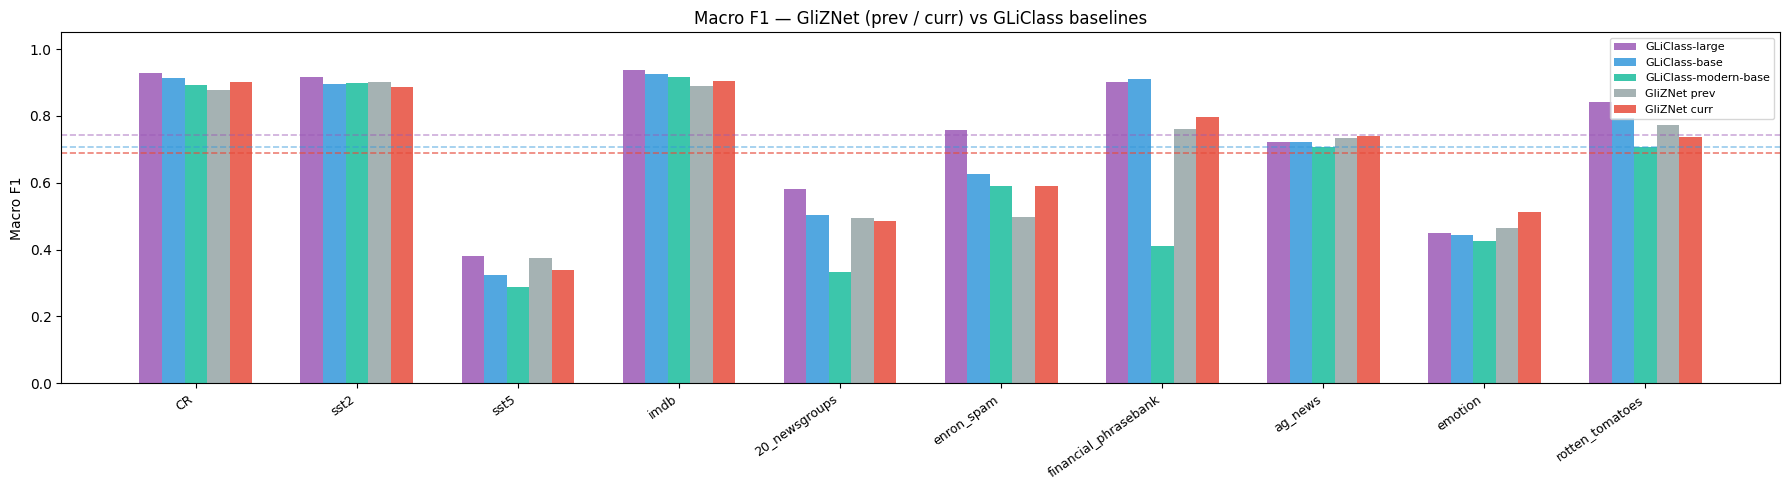

  GliZNet curr (ours)          0.6888

Baseline                         Avg F1  Ours - Baseline
─────────────────────────────────────────────────────────
  GLiClass-large               0.7417  -0.0528
  GLiClass-base                0.7056  -0.0168
  GliZNet prev                 0.6770  +0.0118
  GLiClass-modern-base         0.6170  +0.0718

Per-dataset: curr vs GLiClass-base:
  ▼ CR                                       -0.0126
  ▼ sst2                                     -0.0101
  ▲ sst5                                     +0.0151
  ▼ imdb                                     -0.0211
  ▼ 20_newsgroups                            -0.0183
  ▼ enron_spam                               -0.0360
  ▼ financial_phrasebank                     -0.1124
  ▲ ag_news                                  +0.0175
  ▲ emotion                                  +0.0685
  ▼ rotten_tomatoes                          -0.0586


In [8]:
plot_df = df.drop("AVERAGE").dropna()
x = np.arange(len(plot_df))
w = 0.14

fig, ax = plt.subplots(figsize=(18, 5))
cols   = ["GLiClass-large-v3", "GLiClass-base-v3", "GLiClass-modern-base",
          "GliZNet prev (ours)", "GliZNet curr (ours)"]
labels = ["GLiClass-large", "GLiClass-base", "GLiClass-modern-base",
          "GliZNet prev", "GliZNet curr"]
colors = ["#9b59b6", "#3498db", "#1abc9c", "#95a5a6", "#e74c3c"]
n = len(cols)
offsets = np.linspace(-(n-1)/2, (n-1)/2, n)

for off, col, lbl, clr in zip(offsets, cols, labels, colors):
    ax.bar(x + off * w, plot_df[col], w, label=lbl, color=clr, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.set_title("Macro F1 — GliZNet (prev / curr) vs GLiClass baselines")
ax.legend(loc="upper right", fontsize=8)

avgs = {col: df.loc["AVERAGE", col] for col in cols}
ax.axhline(avgs["GliZNet curr (ours)"],  color="#e74c3c", ls="--", lw=1.2, alpha=0.7)
ax.axhline(avgs["GLiClass-base-v3"],     color="#3498db", ls="--", lw=1.2, alpha=0.5)
ax.axhline(avgs["GLiClass-large-v3"],    color="#9b59b6", ls="--", lw=1.2, alpha=0.5)

plt.tight_layout()
plt.show()

# Summary: how our current model compares to each baseline
ours = avgs["GliZNet curr (ours)"]
print(f"  GliZNet curr (ours)          {ours:.4f}")
print()
print(f"{'Baseline':<30} {'Avg F1':>8}  {'Ours - Baseline':>15}")
print("─" * 57)
baselines = [c for c in cols if c != "GliZNet curr (ours)"]
baseline_labels = [l for c, l in zip(cols, labels) if c != "GliZNet curr (ours)"]
sorted_items = sorted(zip(baselines, baseline_labels), key=lambda x: avgs[x[0]], reverse=True)
for col, lbl in sorted_items:
    a = avgs[col]
    delta = ours - a
    print(f"  {lbl:<28} {a:.4f}  {delta:+.4f}")

print("\nPer-dataset: curr vs GLiClass-base:")
for ds_id in DATASETS:
    ds = ds_id.split("/")[-1]
    delta = df.loc[ds, "GliZNet curr (ours)"] - df.loc[ds, "GLiClass-base-v3"]
    sign = "▲" if delta > 0 else "▼"
    print(f"  {sign} {ds:<40} {delta:+.4f}")